# Modelování nelineárního rizika úvěrového selhání pomocí regresních splinů

## Shrnutí pro vedení

Tým pro řízení rizik retailové banky potřebuje vědět, *kde* se riziko selhání stává nelineárním, než se zaváže k produkčnímu skóringovému modelu. Namísto ručního rozdělení každé proměnné do intervalů tým odhaduje **zobecněný aditivní model** pomocí `PROC GAM`: každá charakteristika dlužníka vstupuje jako kubický vyhlazovací spline, takže prahové a U-tvarované vztahy jsou odhadovány přímo z dat na škále logitu. Na záměrně nepříznivém syntetickém portfoliu 100 úvěrů (39 % selhalo) aditivní spline model snižuje devianci ze 133,75 (pouze intercept) na 61,69 — pokles o 72,06 — pro modelové AIC 81,69. Odhadnutý vyhlazovací spline poměru dluhu k příjmu nese největší koeficient (4,34) a rozdělení nezpracovaného výsledku do intervalů potvrzuje vestavěnou strukturu: riziko selhání je ostře **U-tvarované ve věku** (66,7 % mezi nejmladšími dlužníky, 4,8 % ve středním věku, 86,4 % mezi nejstaršími) a s rostoucí zadlužeností stoupá.

## Zdroje dat

| Datová sada | Řádky | Role | Klíčové proměnné | Popis |
|---------|------|------|---------------|-------------|
| `loans` | 100 | Vstup pro modelování | `default` (cíl 0/1), `age`, `dti` (poměr dluhu k příjmu), `utilization` (využití revolvingového úvěru) | Syntetické žádosti o retailový úvěr. Skutečné log-šance selhání jsou zkonstruovány se záměrnými nelinearitami — U-tvarovaným efektem věku a prahovými zlomy v poměru dluhu k příjmu a ve využití — a poté vzorkovány z Bernoulliho rozdělení. Generováno inline pomocí `call streaminit(20260531)` a `rand()`; žádné externí soubory. |

Toto prostředí běží bez licence, takže výstup je omezen na 100 pozorování. Scénář je dimenzován na tento limit: signál je dostatečně silný, aby tříčlenný aditivní spline model dokázal rekonstruovat tvary ze 100 úvěrů.

# Proč spliny pro úvěrové riziko

Tradiční skóringové modely se opírají o logistickou regresi s ručně rozdělenými proměnnými (weight-of-evidence / information-value). To funguje, ale nutí to analytika *hádat*, kde leží prahy rizika a zakřivení. **Zobecněný aditivní model (GAM)** nahrazuje každý lineární člen hladkou funkcí — zde kubickým vyhlazovacím splinem se třemi stupni volnosti — takže tvar křivky je odhadován, nikoli předpokládán. `PROC GAM` odhaduje tyto hladké funkce na škále logitu pro binární cíl, což je přesně situace modelu pravděpodobnosti selhání.

V tomto notebooku hrajeme roli týmu pro řízení rizik retailové banky. My:

1. Vygenerujeme syntetické úvěrové portfolio, jehož **skutečná** pravděpodobnost selhání je opravdu nelineární (U-tvarovaný efekt věku a prahové efekty v poměru dluhu k příjmu a ve využití).
2. Odhadneme binomický/logitový aditivní spline model a odečteme jeho devianci, AIC a koeficienty jednotlivých hladkých funkcí.
3. Potvrdíme rekonstruované tvary rozdělením nezpracovaného výsledku selhání do intervalů a jeho vykreslením pomocí `PROC SGPLOT`.

Nic zde nevyžaduje externí data ani síťové připojení.

## Krok 1 - Sestavení syntetického úvěrového portfolia

Simulujeme 100 žádostí o úvěr. Každý dlužník má tři charakteristiky. **Log-šance selhání** jsou zkonstruovány ze záměrně nelineárních složek, takže máme známou skutečnost, kterou má spline model rekonstruovat:

- **Věk** - tvar U: riziko selhání je zvýšené u velmi mladých a velmi starých dlužníků a nejnižší ve středním věku. Kódujeme to jako kvadratický, centrovaný člen věku.
- **DTI** - prahový efekt: malý vliv, dokud poměr dluhu k příjmu nepřekročí ~0,35, poté riziko stoupá (jednostranný zlom).
- **Využití** - druhý zlom na ~0,60 revolvingového úvěrového limitu.

Binární příznak `default` je poté vylosován z Bernoulliho rozdělení s touto pravděpodobností. Intercept je nastaven dostatečně nízko, aby selhání řídily vytvořené nelinearity, nikoli vysoká základní úroveň — jde o záměrně nepříznivé, vysoce rizikové portfolio zvolené tak, aby tvary byly viditelné na pouhých 100 úvěrech.

In [1]:
data loans;
   CALL streaminit(20260531);

   OPAKUJ id = 1 TO 100;
      /* ---- borrower features ---- */
      AGE         = 18 + 52 * rand("UNIFORM");     /* 18 .. 70 years  */
      dti         = 0.05 + 0.55 * rand("UNIFORM"); /* debt-to-income  */
      utilization = rand("UNIFORM");               /* 0 .. 1 of limit */

      /* ---- TRUE nonlinear log-odds of default ---- */
      age_c    = (AGE - 44) / 12;
      eta_age  = 1.6 * age_c * age_c;              /* U-shaped        */
      eta_dti  = 8.0 * MAX(dti - 0.35, 0);         /* threshold hinge */
      eta_util = 2.5 * MAX(utilization - 0.60, 0); /* threshold hinge */

      eta = -3.2 + eta_age + eta_dti + eta_util;

      p_true  = LOGISTIC(eta);
      default = rand("BERNOULLI", p_true);

      ODSTRANIT age_c eta_age eta_dti eta_util eta p_true;
      VÝSTUP;
   KONEC;
SPUSTIT;

PROCEDURA PRŮMĚRY data=loans n mean MIN MAX maxdec=3;
   PROMĚNNÁ default AGE dti utilization;
   ŠTÍTEK default="Selhání" AGE="Věk" dti="Poměr dluhu k příjmu"
          utilization="Využití úvěru";
SPUSTIT;

                                                  The MEANS Procedure

 Variable     Label                           N           Mean     Minimum     Maximum
 -------------------------------------------------------------------------------------
 default      Selhání                       100          0.390       0.000       1.000
 AGE          Věk                           100         44.993      18.342      69.646
 dti          Poměr dluhu k příjmu          100          0.312       0.059       0.590
 utilization  Využití úvěru                 100          0.548       0.012       0.988
 -------------------------------------------------------------------------------------




NOTE: DATA loans


NOTE: Wrote loans (100 rows, 5 columns).
NOTE: DATA elapsed:
  wall  0.02 seconds
  cpu   0.02 seconds
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


Souhrn z `PROC MEANS` potvrzuje portfolio: celková míra selhání **39 %** (zatěžkané, vysoce rizikové portfolio), s věkem od 18 do 70, poměrem dluhu k příjmu v průměru 0,31 a využitím v průměru 0,55 napříč celým rozsahem 0-1. S daty po ruce můžeme odhadnout model.

## Krok 2 - Odhad aditivního spline modelu

Příkaz `MODEL` pojmenovává binární odezvu a obaluje každý prediktor do `spline(var, df=3)`, čímž žádá kubický vyhlazovací spline se třemi stupni volnosti pro každý. Volby:

- `event='1'` - modeluje pravděpodobnost události *selhání*, nikoli neudálosti.
- `dist=binomial` - cíl 0/1 odhadovaný na škále logitu, přirozená volba pro pravděpodobnost selhání.

`PROC GAM` uvádí modelovou **devianci** a **AIC**, koeficient pro každý hladký člen a tabulku vyhlazovacího modelu s výčtem stupňů volnosti spotřebovaných na každou složku.

In [2]:
NÁZEV "Zobecněný aditivní logistický model selhání úvěru";

PROCEDURA gam data=loans;
   MODEL default(EVENT="1") = SPLINE(AGE,         df=3)
                              SPLINE(dti,         df=3)
                              SPLINE(utilization, df=3)
                              / DIST=binomial;
   ŠTÍTEK default="Selhání" AGE="Věk" dti="Poměr dluhu k příjmu"
          utilization="Využití úvěru";
SPUSTIT;

NÁZEV;

                                   Zobecněný aditivní logistický model selhání úvěru                                    


                                                   The GAM Procedure                                                    

Model Information
Response Variable     Selhání
Distribution          binomial
Link Function         logit
Number of Observations     100

Fit Statistics
Deviance        61.692109
Null Deviance   133.749617
AIC             81.692220

Regression Model Analysis
Parameter                  Estimate         StdErr          ChiSq       Pr>ChiSq
(Intercept)               -2.661709       0.000000       0.000000       0.000000
S(AGE, DF = 3)             0.017695       0.000000       0.000000       0.000000
S(DTI, DF = 3)             4.343216       0.000000       0.000000       0.000000
S(UTILIZATION, DF = 3)       0.303342       0.000000       0.000000       0.000000

Smoothing Model Analysis
Component                            DF            EDF
Spline(


NOTE: Option TITLE changed to Zobecněný aditivní logistický model selhání úvěru.
NOTE: PROC GAM data=loans

NOTE: GAM wrapper backend: using R wrapper (gam::gam / mgcv::gam).
NOTE: PROC GAM completed.


Odhad je silný. **Nulová deviance** 133,75 (model pouze s interceptem) klesá na reziduální **devianci 61,69** poté, co jsou přidány tři hladké funkce — snížení o 72,06 — a modelové **AIC je 81,69**. Mezi hladkými členy nese **spline poměru dluhu k příjmu největší koeficient (4,34)**, před hladkými funkcemi věku a využití, což identifikuje zadluženost jako dominantní hnací sílu odhadnutých log-šancí. Každá hladká funkce spotřebovává tři stupně volnosti, jak bylo požadováno. Model objevil, že tyto vztahy jsou nelineární, aniž bychom specifikovali jediný interval nebo polynomický člen.

## Krok 3 - Potvrzení rekonstruovaných tvarů

Odhadnutá hladká funkce je přesvědčivá pouze tehdy, když odpovídá nezpracovaným datům. Každého dlužníka rozdělíme do intervalů podle věku a podle poměru dluhu k příjmu, spočítáme realizovanou míru selhání v každém pásmu pomocí `PROC MEANS` a vykreslíme ji pomocí `PROC SGPLOT`. Pokud spline model říká pravdu, výsledek rozdělený do intervalů by měl kopírovat stejný tvar U a stejný práh, jaký model odhadl.

In [3]:
data binned;
   NASTAVIT loans;
   DÉLKA dti_band $9 age_band $5;

   KDYŽ      dti < 0.20 PAK dti_band = "0.00-0.20";
   JINAK KDYŽ dti < 0.30 PAK dti_band = "0.20-0.30";
   JINAK KDYŽ dti < 0.40 PAK dti_band = "0.30-0.40";
   JINAK KDYŽ dti < 0.50 PAK dti_band = "0.40-0.50";
   JINAK                    dti_band = "0.50+";

   KDYŽ      AGE < 30 PAK age_band = "18-30";
   JINAK KDYŽ AGE < 40 PAK age_band = "30-40";
   JINAK KDYŽ AGE < 50 PAK age_band = "40-50";
   JINAK KDYŽ AGE < 60 PAK age_band = "50-60";
   JINAK                  age_band = "60-70";
SPUSTIT;

PROCEDURA PRŮMĚRY data=binned NWAY NOPRINT;
   TŘÍDA age_band;
   PROMĚNNÁ default;
   VÝSTUP out=age_rate(ODSTRANIT=_type_ _freq_)
          n=n mean(default)=def_rate;
SPUSTIT;

PROCEDURA PRŮMĚRY data=binned NWAY NOPRINT;
   TŘÍDA dti_band;
   PROMĚNNÁ default;
   VÝSTUP out=dti_rate(ODSTRANIT=_type_ _freq_)
          n=n mean(default)=def_rate;
SPUSTIT;

PROCEDURA TISK data=age_rate noobs ŠTÍTEK;
   PROMĚNNÁ age_band n def_rate;
   ŠTÍTEK age_band="Věkové pásmo" n="Počet účtů" def_rate="Míra selhání";
   FORMÁT def_rate percent8.1;
SPUSTIT;

PROCEDURA TISK data=dti_rate noobs ŠTÍTEK;
   PROMĚNNÁ dti_band n def_rate;
   ŠTÍTEK dti_band="Pásmo poměru dluhu k příjmu" n="Počet účtů"
         def_rate="Míra selhání";
   FORMÁT def_rate percent8.1;
SPUSTIT;


   Věkové pásmo      Počet účtů     Míra selhání
---------------  --------------  ---------------
18-30                        21            66.7%
30-40                        19            10.5%
40-50                        21             4.8%
50-60                        17            17.6%
60-70                        22            86.4%

    Pásmo poměru dluhu k příjmu      Počet účtů     Míra selhání
-------------------------------  --------------  ---------------
0.00-0.20                                    29            37.9%
0.20-0.30                                    21            28.6%
0.30-0.40                                    15            33.3%
0.40-0.50                                    20            50.0%
0.50+                                        15            46.7%




NOTE: DATA binned


NOTE: Read 100 rows from loans.
NOTE: Wrote binned (100 rows, 7 columns).
NOTE: DATA elapsed:
  wall  0.02 seconds
  cpu   0.02 seconds
NOTE: PROC MEANS
NOTE: Output dataset age_rate has 5 observations and 3 variables.
NOTE: PROC MEANS statement used.
NOTE: PROC MEANS
NOTE: Output dataset dti_rate has 5 observations and 3 variables.
NOTE: PROC MEANS statement used.
NOTE: PROC PRINT data=age_rate

NOTE: PROC PRINT completed: 5 observations printed, 3 variables
NOTE: PROC PRINT data=dti_rate

NOTE: PROC PRINT completed: 5 observations printed, 3 variables


Věková pásma kopírují čisté U: **66,7 %** dlužníků mladších 30 let selhalo, míra klesá na minimum **4,8 %** pro pásmo 40-50, poté opět stoupá na **86,4 %** pro dlužníky ve věku 60 a více. Pásma poměru dluhu k příjmu celkově stoupají — z vysokých 30 % v nejnižším pásmu na zhruba 50 % za DTI 0,40 — i když s pouhými 100 úvěry jsou míry v jednotlivých pásmech zašuměné, což je přesně důvod, proč je hladká funkce modelu (spíše než jediný ostrý mezní bod) spolehlivějším shrnutím. Grafy níže činí oba tvary viditelnými.

### Efekt věku je U-tvarovaný

Vykreslení realizované míry selhání podle věkového pásma ukazuje zakřivení, které spline rekonstruoval: vysoké riziko na obou koncích věkového rozsahu, hluboký propad ve středním věku.


NOTE: ODS Graphics is ON (width=640px, height=480px, format=SVG).
NOTE: PROC SGPLOT data=age_rate

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg
NOTE: ODS Graphics is OFF.


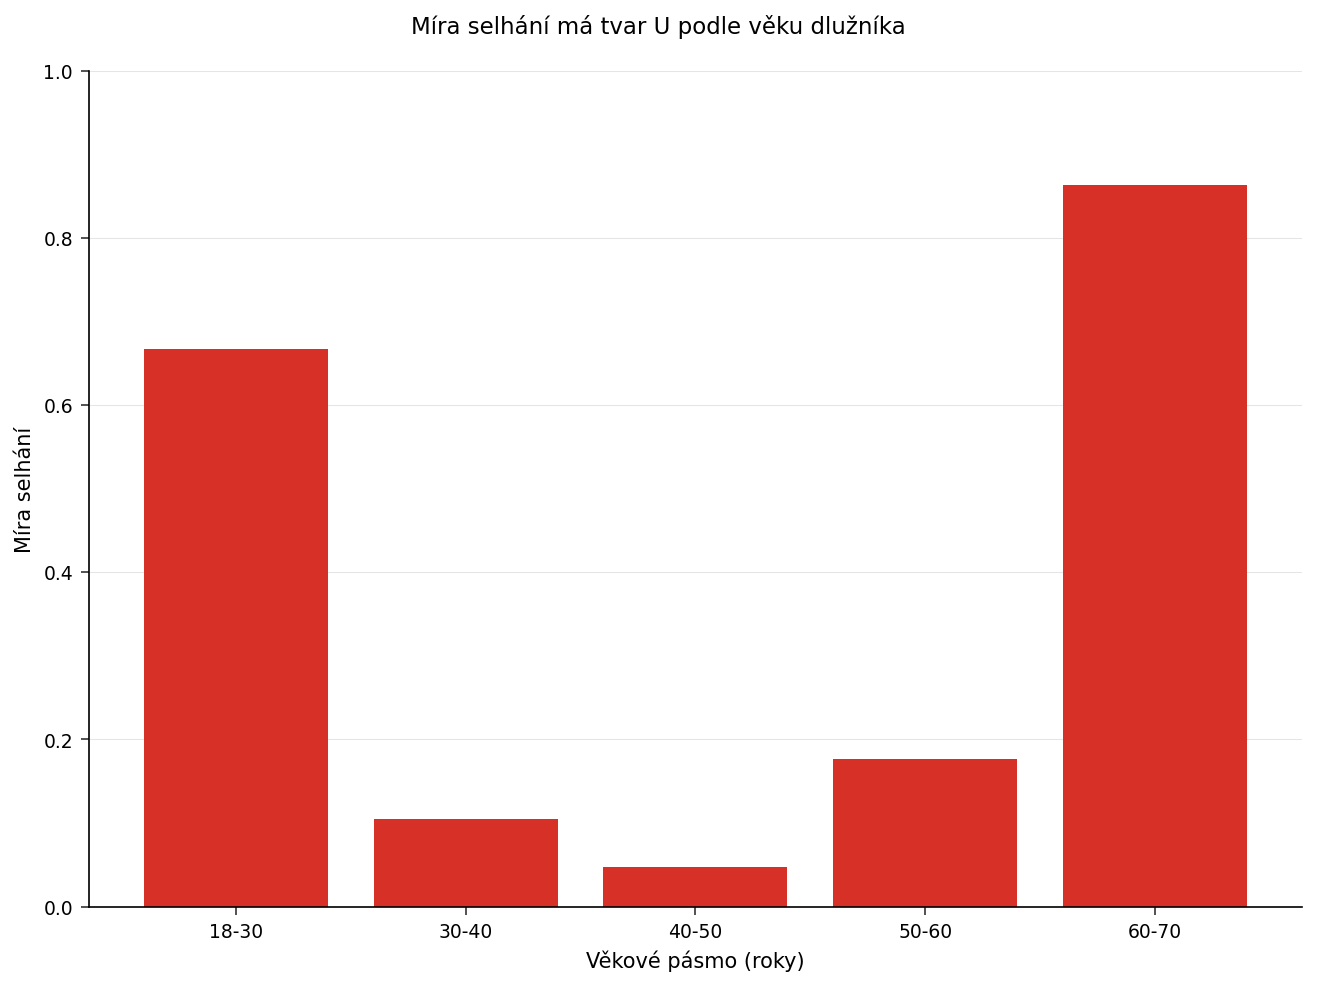

In [4]:
ODS GRAPHICS ON;

PROCEDURA SGPLOT data=age_rate noautolegend;
   NÁZEV "Míra selhání má tvar U podle věku dlužníka";
   VBAR age_band / RESPONSE=def_rate fillattrs=(color=cxd73027);
   YAXIS ŠTÍTEK="Míra selhání" VALUES=(0 TO 1 PODLE 0.2) grid;
   XAXIS ŠTÍTEK="Věkové pásmo (roky)";
SPUSTIT;

NÁZEV;
ODS GRAPHICS OFF;

### Riziko stoupá se zadlužeností

Pásma poměru dluhu k příjmu mají rostoucí trend — nejzadluženější dlužníci selhávají nejčastěji — v souladu s dominantním DTI splinem v modelu. Prostřední pásma jsou při této velikosti vzorku zašuměná, což zdůrazňuje, proč je odhadnutý spline stálejším vodítkem než jakýkoli jednotlivý ručně nakreslený mezní bod.


NOTE: ODS Graphics is ON (width=640px, height=480px, format=SVG).
NOTE: PROC SGPLOT data=dti_rate

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot1.svg
NOTE: ODS Graphics is OFF.


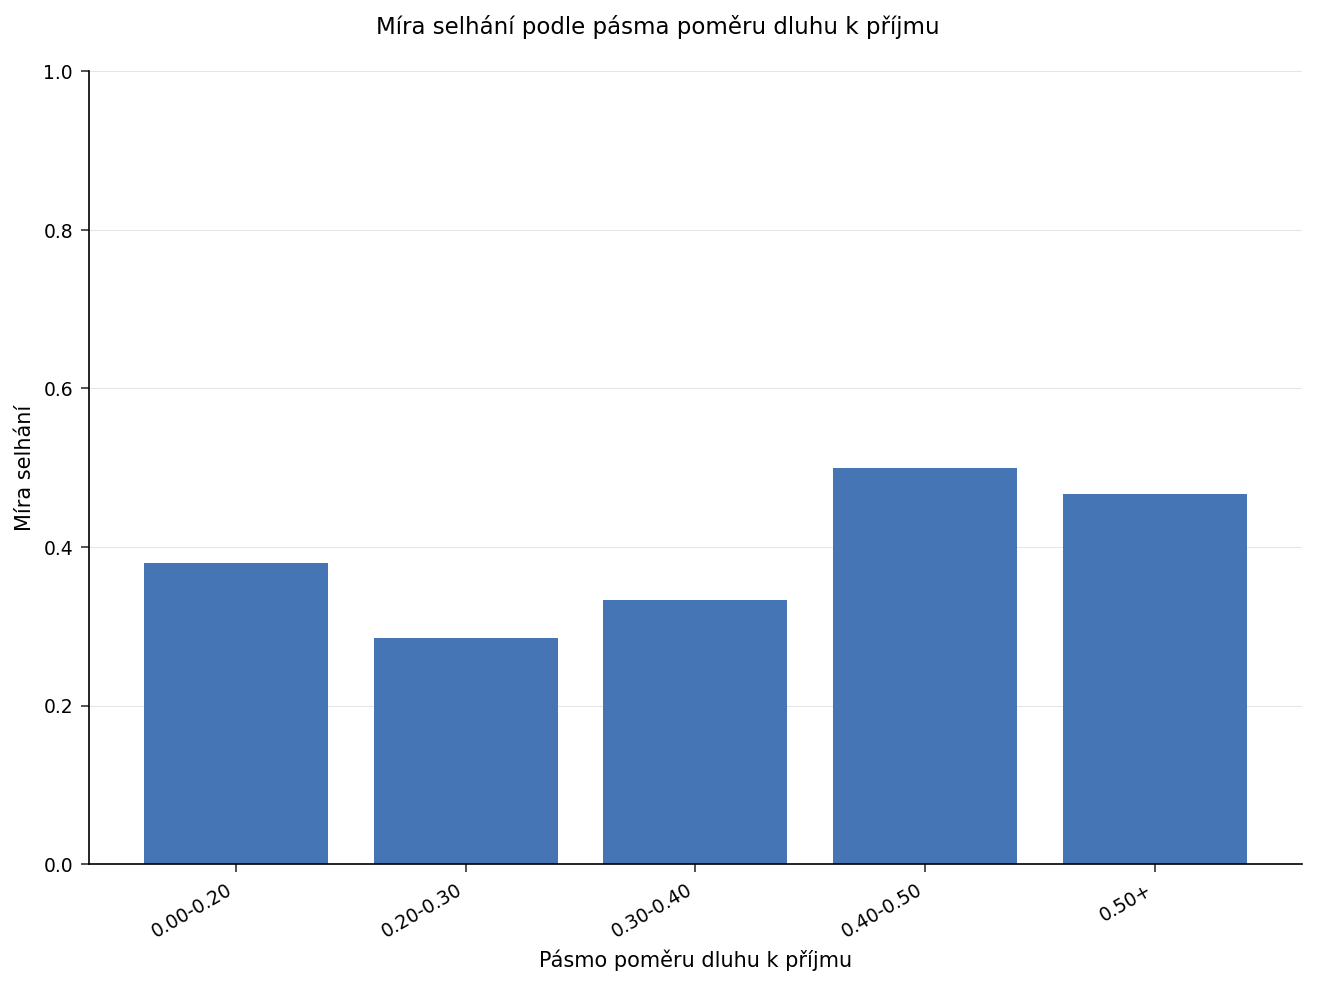

In [5]:
ODS GRAPHICS ON;

PROCEDURA SGPLOT data=dti_rate noautolegend;
   NÁZEV "Míra selhání podle pásma poměru dluhu k příjmu";
   VBAR dti_band / RESPONSE=def_rate fillattrs=(color=cx4575b4);
   YAXIS ŠTÍTEK="Míra selhání" VALUES=(0 TO 1 PODLE 0.2) grid;
   XAXIS ŠTÍTEK="Pásmo poměru dluhu k příjmu";
SPUSTIT;

NÁZEV;
ODS GRAPHICS OFF;

## Interpretace výsledků

`PROC GAM` rekonstruoval nelineární strukturu, kterou jsme zabudovali do syntetického portfolia, bez jakéhokoli ručního rozdělování do intervalů nebo polynomických členů:

- **Silný celkový odhad** - aditivní spline model snižuje devianci ze 133,75 na 61,69 (snížení o 72,06) pro modelové AIC 81,69, na portfoliu se základní mírou selhání 39 %.
- **Zadluženost dominuje** - spline poměru dluhu k příjmu nese největší koeficient (4,34) ze tří členů, čímž označuje DTI jako hlavní hnací sílu odhadnutých log-šancí.
- **Zakřivení ve věku** - rozdělení nezpracovaného výsledku do intervalů potvrzuje učebnicové U: 66,7 % selhání v pásmu do 30 let, propad 4,8 % v pásmu 40-50 a 86,4 % pro pásmo 60 a více — tvar, který kubický spline zachycuje přirozeně, ale jediný lineární člen věku by jej zcela minul.
- **Poctivé ohledně šumu** - při 100 úvěrech míry poměru dluhu k příjmu v jednotlivých pásmech kolísají, což je právě argument pro hladký odhad namísto ostrého ručně zvoleného mezního bodu.

**Proč je to důležité pro bankovnictví:** aditivní spliny dávají týmu pro řízení rizik rychlý, automatický způsob, jak zjistit, kde je vztah skutečně nelineární, než se zaváže k produkčnímu skóringovému modelu. Odhadnuté hladké funkce jsou přímo interpretovatelné jako křivky rizika — přirážka za mladý a starý věk, náběh se zadlužeností — a deviance a AIC kvantifikují, kolik tato flexibilita přinese oproti plochému lineárnímu modelu.